# Member 2 — Phase 2: Data Quality & Target Analysis

**Project:** Hotel Booking Demand — Cancellation Risk  
**Owner area:** Member 2 — Data quality + target analysis

This notebook formally checks missing values, exact duplicates, suspicious values, target distribution, and class imbalance using the actual `hotel_bookings.csv` dataset. It documents issues for later preprocessing without modifying the raw data.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../../data/raw/hotel_bookings.csv")
RESULTS_DIR = Path("../../results/eda")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Target validation and distribution

Question: Is the target complete and valid, and how balanced are the two classes?

Target unique values: [0, 1]
Target missing values: 0

Counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Percentages:
is_canceled
0    62.958
1    37.042
Name: proportion, dtype: float64


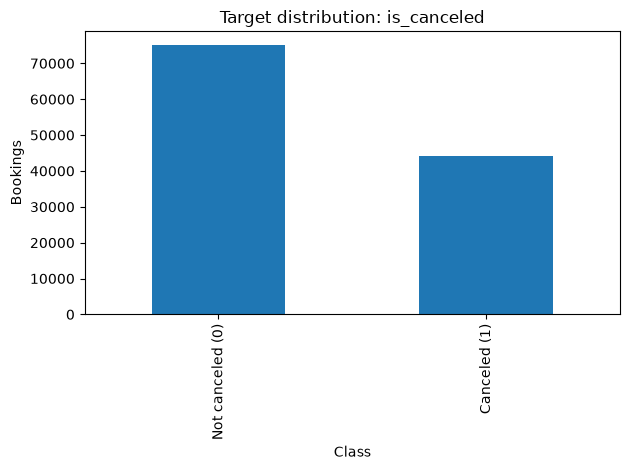

In [11]:
target = "is_canceled"

target_counts = df[target].value_counts(dropna=False).sort_index()
target_pct = (df[target].value_counts(normalize=True, dropna=False).sort_index() * 100).round(3)

print("Target unique values:", sorted(df[target].dropna().unique().tolist()))
print("Target missing values:", df[target].isna().sum())
print("\nCounts:")
print(target_counts)
print("\nPercentages:")
print(target_pct)

ax = target_counts.rename(index={0: "Not canceled (0)", 1: "Canceled (1)"}).plot(kind="bar")
ax.set_title("Target distribution: is_canceled")
ax.set_xlabel("Class")
ax.set_ylabel("Bookings")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "m2_target_distribution.png", dpi=150)
plt.show()

**Observation → Interpretation → Why it matters**

- **Observation:** The target contains only `0` and `1`, with no missing values. There are **75,166 non-canceled bookings (62.958%)** and **44,224 canceled bookings (37.042%)**.
- **Interpretation:** The classes are unequal but both classes are well represented. This is a moderate imbalance rather than an extreme rare-event problem.
- **Why it matters:** Model evaluation should consider more than overall accuracy. Precision, recall, F1-score, and ROC-AUC should also be examined to understand how well the model identifies both canceled and non-canceled bookings. Any resampling or other imbalance-handling technique should only be reported, and any later imbalance treatment should be justified rather than applied automatically.

## 2. Missing-value audit

Question: Which variables contain missing data, and how severe is each issue?

In [12]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3)
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


**Observation → Interpretation → Why it matters**

- `company`: **112,593 missing (94.306%)** — extremely sparse and identifier-like.
- `agent`: **16,340 missing (13.686%)** — meaningful missingness and identifier-like.
- `country`: **488 missing (0.409%)** — small but non-zero categorical missingness.
- `children`: **4 missing (0.003%)** — very small numeric missingness.

These values should be handled in Phase 3 using explicit, reproducible rules. The notebook does not impute or delete any rows during EDA.

## 3. Exact duplicate audit

Question: How many rows are exact duplicates, and would blind removal materially change the data?

In [13]:
duplicate_count = int(df.duplicated().sum())
duplicate_pct = duplicate_count / len(df) * 100
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_pct:.3f}%)")

all_duplicate_rows = df[df.duplicated(keep=False)]
print("\nTarget counts among rows participating in duplicate groups:")
print(all_duplicate_rows[target].value_counts())

before_rate = df[target].mean() * 100
after_dedup = df.drop_duplicates()
after_rate = after_dedup[target].mean() * 100
print(f"\nCancellation rate before deduplication: {before_rate:.3f}%")
print(f"Cancellation rate after exact deduplication: {after_rate:.3f}%")
print(f"Rows after exact deduplication: {len(after_dedup):,}")

Exact duplicate rows: 31,994 (26.798%)

Target counts among rows participating in duplicate groups:
is_canceled
1    23451
0    16714
Name: count, dtype: int64

Cancellation rate before deduplication: 37.042%
Cancellation rate after exact deduplication: 27.490%
Rows after exact deduplication: 87,396


**Observation → Interpretation → Why it matters**

- **Observation:** There are **31,994 exact duplicate rows (26.798%)**. Removing exact duplicates would reduce the dataset to **87,396 rows** and change the cancellation rate from **37.042%** to **27.490%**.
- **Interpretation:** Duplicate removal is not a harmless formatting step. Because the dataset has no explicit booking ID, some identical rows may represent genuinely separate bookings with the same recorded attributes.
- **Why it matters:**Duplicate handling should be investigated further during Phase 3 cleaning and supported by a clear justification. Do **not** drop duplicates automatically just because `DataFrame.duplicated()` flags them.

## 4. Suspicious-value checks

Question: Are there values that are technically readable but need domain review before modelling?

In [14]:
total_guests = df[["adults", "children", "babies"]].fillna(0).sum(axis=1)
total_nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

checks = pd.DataFrame({
    "check": [
        "Bookings with zero total guests",
        "Bookings with adults = 0",
        "Bookings with adults > 10",
        "Bookings with children > 5",
        "Bookings with babies > 5",
        "Bookings with zero total nights",
        "ADR < 0",
        "ADR = 0",
        "ADR > 500",
        "Arrival week outside 1..53",
        "Arrival day outside 1..31",
    ],
    "count": [
        int((total_guests == 0).sum()),
        int((df["adults"] == 0).sum()),
        int((df["adults"] > 10).sum()),
        int((df["children"] > 5).sum()),
        int((df["babies"] > 5).sum()),
        int((total_nights == 0).sum()),
        int((df["adr"] < 0).sum()),
        int((df["adr"] == 0).sum()),
        int((df["adr"] > 500).sum()),
        int(((df["arrival_date_week_number"] < 1) | (df["arrival_date_week_number"] > 53)).sum()),
        int(((df["arrival_date_day_of_month"] < 1) | (df["arrival_date_day_of_month"] > 31)).sum()),
    ]
})
checks

,check,count
0,Bookings with zero total guests,180
1,Bookings with adults = 0,403
2,Bookings with adults > 10,12
3,Bookings with children > 5,1
4,Bookings with babies > 5,2
5,Bookings with zero total nights,715
6,ADR < 0,1
7,ADR = 0,1959
8,ADR > 500,3
9,Arrival week outside 1..53,0


In [15]:
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
arrival_dates = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_map),
    "day": df["arrival_date_day_of_month"],
}, errors="coerce")
print("Invalid constructed arrival dates:", int(arrival_dates.isna().sum()))
print("ADR min/max:", df["adr"].min(), df["adr"].max())
print("Adults min/max:", df["adults"].min(), df["adults"].max())
print("Children min/max:", df["children"].min(), df["children"].max())
print("Babies min/max:", df["babies"].min(), df["babies"].max())

Invalid constructed arrival dates: 0
ADR min/max: -6.38 5400.0
Adults min/max: 0 55
Children min/max: 0.0 10.0
Babies min/max: 0 10


**Observation → Interpretation → Why it matters**

- **180 rows** have zero total guests; **715 rows** have zero total nights. These may be unusual but need business-context review before being labelled invalid.
- `adults` reaches **55**, `children` reaches **10**, and `babies` reaches **10**. A small number of very large party-size values should be reviewed rather than automatically clipped.
- `adr` includes **1 negative value**, **1,959 zero values**, and **3 values above 500**, with a maximum of **5,400**. These are important candidates for Phase 3 outlier/validity decisions.
- Constructed arrival dates are valid for all rows, and the calendar day/week ranges are valid.

EDA flags these records; cleaning decisions belong to Phase 3.

## 5. Leakage-support check

Member 1 already flagged `reservation_status` and `reservation_status_date`. This check quantifies why `reservation_status` is unsafe as an ordinary predictor.

In [16]:
status_target = pd.crosstab(df["reservation_status"], df[target])
status_target

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


`reservation_status` perfectly separates the target in this dataset (`Check-Out` only occurs with `is_canceled=0`, while `Canceled` and `No-Show` only occur with `is_canceled=1`). This is strong evidence of post-outcome leakage. The Phase 3 feature-availability audit should exclude it from normal cancellation-risk predictors unless the prediction timing somehow makes it legitimately available.

## Phase 2 handoff from Member 2

**Data-quality decisions that Phase 3 must resolve:**

1. How to treat the four missing-value columns (`company`, `agent`, `country`, `children`).
2. Whether exact duplicates represent redundant records or genuine repeated bookings; avoid blind deletion.
3. How to handle zero-guest and zero-night records.
4. How to handle extreme/invalid-looking `adr` and unusually large guest counts.
5. Exclude/document post-outcome leakage fields such as `reservation_status` and `reservation_status_date`.
6. Keep evaluation metrics beyond accuracy because the target split is about 63% vs 37%.

No raw data has been altered in this notebook.